In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nikitagupta1812/titanictoy-simpleimputer/titanic_toy.csv


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('/kaggle/input/datasets/nikitagupta1812/titanictoy-simpleimputer/titanic_toy.csv')

In [5]:
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [6]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [8]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [9]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [10]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [12]:
X_train.shape

(712, 3)

In [13]:
X_test.shape

(179, 3)

In [14]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [15]:
mean_Age = X_train['Age'].mean()
median_Age = X_train['Age'].median()

mean_Fare = X_train['Fare'].mean()
median_Fare = X_train['Fare'].median()


In [16]:
X_train['Age_median'] = X_train['Age'].fillna(median_Age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_Age)

In [17]:
X_train['Fare_median'] = X_train['Age'].fillna(median_Fare)
X_train['Fare_mean'] = X_train['Age'].fillna(mean_Fare)

In [18]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
154,NaN,7.3125,0,28.75,29.785904,14.4583,32.617597
182,9.0,31.3875,6,9.00,9.000000,9.0000,9.000000
139,24.0,79.2000,0,24.00,24.000000,24.0000,24.000000
117,29.0,21.0000,1,29.00,29.000000,29.0000,29.000000
88,23.0,263.0000,5,23.00,23.000000,23.0000,23.000000


In [19]:
print('Original Age Variable  Variance: ', X_train['Age'].var())
print("Age Vairance after median Imputation", X_train['Age_median'].var())
print("Age Vairance after mean Imputation", X_train['Age_mean'].var())
print('\n')
print('Original Fare Variable  Variance: ', X_train['Fare'].var())
print("Fare Vairance after median Imputation", X_train['Fare_median'].var())
print("Fare Vairance after mean Imputation", X_train['Fare_mean'].var())


Original Age Variable  Variance:  204.3495133904614
Age Vairance after median Imputation 161.9895663346054
Age Vairance after mean Imputation 161.81262452718673


Original Fare Variable  Variance:  2448.197913706318
Fare Vairance after median Imputation 200.55085535155024
Fare Vairance after mean Imputation 163.1347828052615


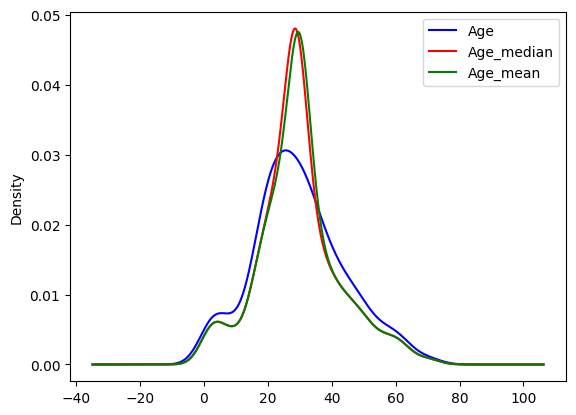

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111)

## Original Variable Distribution
X_train['Age'].plot(kind='kde',ax=ax, color='blue')

## Variable Imputed with the median
X_train['Age_median'].plot(kind='kde',ax=ax,color='red')

## Variable Imputed with the mean
X_train['Age_mean'].plot(kind='kde',ax=ax,color='green')


## Add Legends
lines,labels= ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

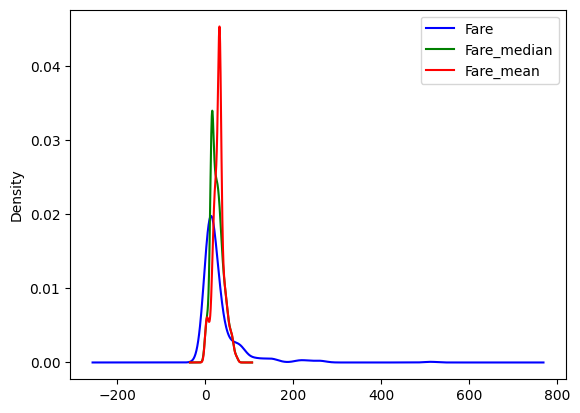

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)

## Original Variable Distribution
X_train['Fare'].plot(kind='kde',ax=ax, color='blue')

## Variable Imputed with the median
X_train['Fare_median'].plot(kind='kde',ax=ax,color='green')


## Variable Imputed with the mean
X_train['Fare_mean'].plot(kind='kde',ax=ax,color='red')
## Add Legends
lines,labels= ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [22]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,204.349513,204.349513
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,90.432552,49.169279
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,-4.649792,-5.237797
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,164.430718,161.328946
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,161.812625,161.812625
Fare_median,204.349513,90.432552,-4.649792,164.430718,161.812625,200.550855,154.655944
Fare_mean,204.349513,49.169279,-5.237797,161.328946,161.812625,154.655944,163.134783


In [23]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,1.000000,1.000000
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,0.128809,0.077538
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,-0.198528,-0.247957
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.912278,0.992420
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.898243,0.995939
Fare_median,1.000000,0.128809,-0.198528,0.912278,0.898243,1.000000,0.855029
Fare_mean,1.000000,0.077538,-0.247957,0.992420,0.995939,0.855029,1.000000


<Axes: >

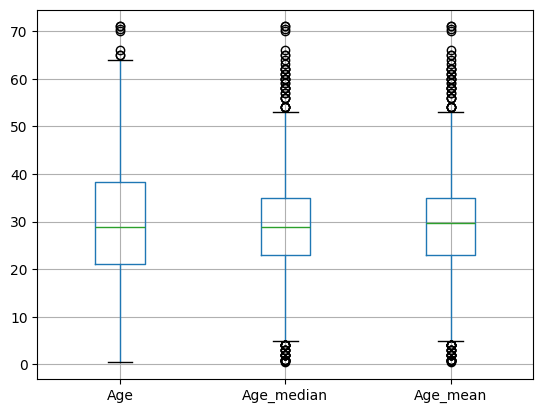

In [24]:
X_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

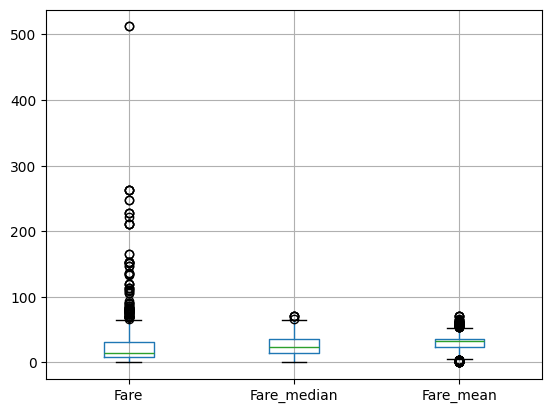

In [25]:
X_train[['Fare','Fare_median','Fare_mean']].boxplot()

## Using SKLEARN

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [27]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [28]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [29]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [30]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [31]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [32]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [33]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])

## Arbitrary Value Imputation


In [34]:
import pandas as pd

X_train = pd.DataFrame(X_train, columns=['Age','Fare','Family'])
X_test = pd.DataFrame(X_test, columns=['Age','Fare','Family'])

In [35]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['age_minus1'] = X_train['Age'].fillna(-1)

X_train['Fare_99'] = X_train['Fare'].fillna(999)
X_train['fare_minus1'] = X_train['Fare'].fillna(-1)